In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, adjusted_rand_score

import torch
import torch.nn as nn
import torch.nn.functional as F

from datetime import date

# Reproducibility
np.random.seed(123)
torch.manual_seed(123)

In [ ]:
block_sizes = [400, 350, 250]
num_blocks = len(block_sizes)
num_nodes = sum(block_sizes)

# SBM probability matrix:
# - Higher values on the diagonal mean stronger within-community ties
# - Lower off-diagonal values mean weaker between-community ties
P = np.array([
    [0.06, 0.01, 0.005],
    [0.01, 0.05, 0.008],
    [0.005, 0.008, 0.04]
])

In [ ]:
G = nx.stochastic_block_model(block_sizes, P, seed=123)

# Basic graph summary
num_edges = G.number_of_edges()
density = nx.density(G)

print("Synthetic graph summary:")
print("  Nodes:", num_nodes)
print("  Edges:", num_edges)
print("  Density:", density)

Synthetic graph summary:
  Nodes: 1000
  Edges: 11845
  Density: 0.023713713713713714


In [ ]:
true_labels = np.concatenate([
    np.zeros(block_sizes[0], dtype=int),
    np.ones(block_sizes[1], dtype=int),
    2 * np.ones(block_sizes[2], dtype=int)
])

# -----------------------------------------------------------------------------
# Step 4: Create synthetic node features correlated with communities
# -----------------------------------------------------------------------------
# Idea:
# - Each community has a different feature "center"
# - Each node gets a noisy version of its community center
#
# This lets us compare:
# - Feature-only classifier (logistic regression)
# - GCN that uses both features + network structure

num_features = 8

centers = np.array([
    [2, 0, 0, 1, 0, 0, 1, 0],   # community 0 center
    [0, 2, 0, 0, 1, 0, 0, 1],   # community 1 center
    [0, 0, 2, 0, 0, 1, 1, 0]    # community 2 center
], dtype=float)

noise_sd = 0.8

X = np.zeros((num_nodes, num_features), dtype=float)
X[true_labels == 0] = centers[0] + np.random.normal(0, noise_sd, size=(np.sum(true_labels == 0), num_features))
X[true_labels == 1] = centers[1] + np.random.normal(0, noise_sd, size=(np.sum(true_labels == 1), num_features))
X[true_labels == 2] = centers[2] + np.random.normal(0, noise_sd, size=(np.sum(true_labels == 2), num_features))

# -----------------------------------------------------------------------------
# Part 2: Graph Construction Workflows (Edge list + adjacency)
# -----------------------------------------------------------------------------
# Goal:
# - Show a common workflow: graph -> edge list -> graph -> adjacency (sparse)

# -----------------------------------------------------------------------------
# Step 1: Create an edge list
# -----------------------------------------------------------------------------
edge_list = pd.DataFrame(list(G.edges()), columns=["u", "v"])
print("\nEdge list (first 10 rows):")
print(edge_list.head(10))

# -----------------------------------------------------------------------------
# Step 2: Construct a graph from the edge list (same graph, reconstructed)
# -----------------------------------------------------------------------------
G2 = nx.from_pandas_edgelist(edge_list, source="u", target="v", create_using=nx.Graph())

print("\nReconstructed graph summary:")
print("  Nodes:", G2.number_of_nodes())
print("  Edges:", G2.number_of_edges())


Edge list (first 10 rows):
   u    v
0  0    1
1  0    6
2  0   14
3  0   25
4  0   48
5  0   64
6  0   80
7  0   93
8  0  114
9  0  138

Reconstructed graph summary:
  Nodes: 1000
  Edges: 11845


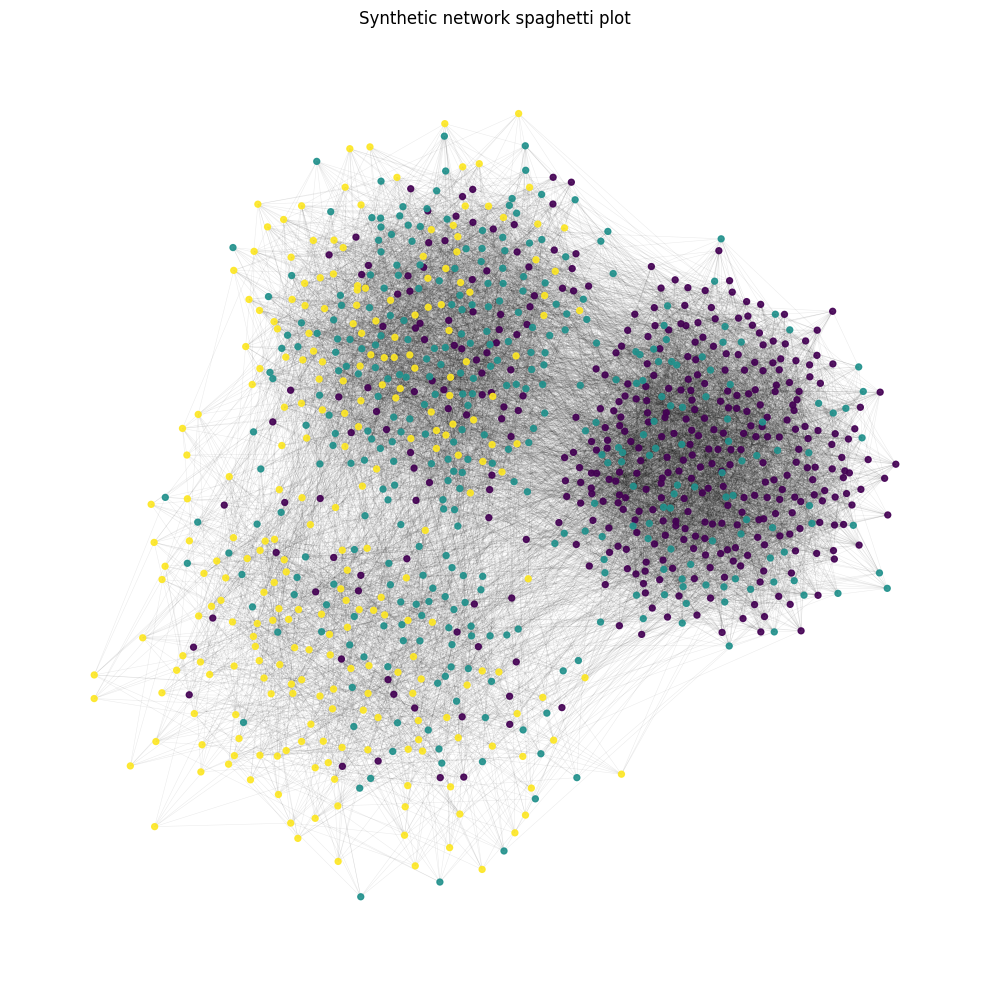


Adjacency matrix:
  Shape: (1000, 1000)
  Nonzeros: 23690

Degree summary:
count    1000.00000
mean       23.69000
std         7.20818
min         6.00000
25%        19.00000
50%        24.00000
75%        29.00000
max        46.00000
dtype: float64


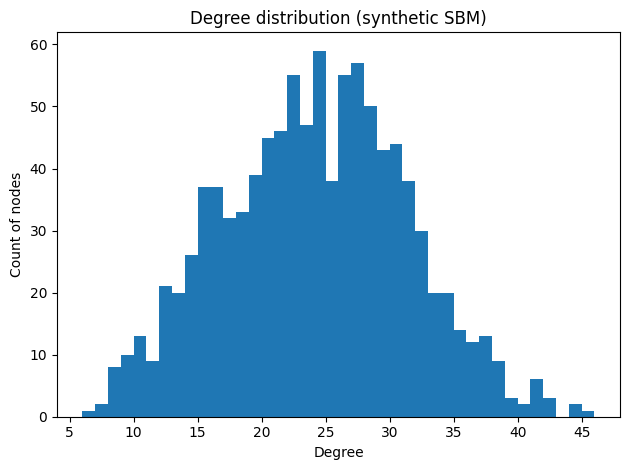

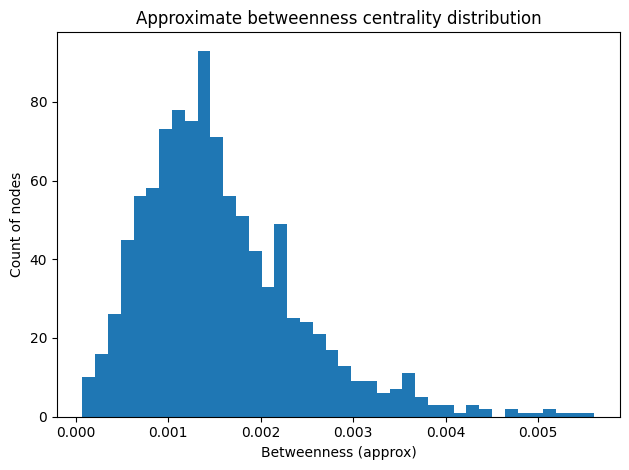

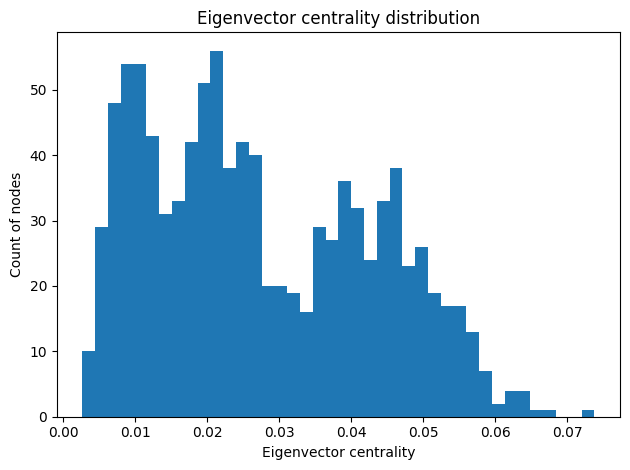

In [ ]:
plt.figure(figsize=(10, 10))

# Layout for the graph
pos = nx.spring_layout(G2, seed=123, k=0.15)

# Draw faint edges first
nx.draw_networkx_edges(
    G2,
    pos,
    alpha=0.08,
    width=0.4
)

# Draw nodes on top, colored by true community
nx.draw_networkx_nodes(
    G2,
    pos,
    node_color=true_labels,
    node_size=18,
    alpha=0.9
)

plt.title("Synthetic network spaghetti plot")
plt.axis("off")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Step 3: Convert the graph to a sparse adjacency matrix
# -----------------------------------------------------------------------------
# Scalability note:
# - Sparse matrices are essential for large graphs.
# - Dense adjacency is O(n^2) memory, which becomes impossible quickly.

A = nx.to_scipy_sparse_array(
    G2,
    nodelist=np.arange(num_nodes),
    format="csr",
    dtype=np.float32
)
print("\nAdjacency matrix:")
print("  Shape:", A.shape)
print("  Nonzeros:", A.nnz)

# -----------------------------------------------------------------------------
# Part 3: Centrality (Examples + Interpretations)
# -----------------------------------------------------------------------------
# Centrality measures quantify "importance" or "influence" of nodes.
# Different centralities reflect different concepts:
# - Degree centrality: local connectivity
# - Betweenness: brokerage / bridging (often expensive to compute)
# - Eigenvector / PageRank: importance in a network of important others

# -----------------------------------------------------------------------------
# Step 1: Degree centrality (fast)
# -----------------------------------------------------------------------------
deg = np.array([d for _, d in G2.degree()])
deg_summary = pd.Series(deg).describe()
print("\nDegree summary:")
print(deg_summary)

plt.figure()
plt.hist(deg, bins=40)
plt.title("Degree distribution (synthetic SBM)")
plt.xlabel("Degree")
plt.ylabel("Count of nodes")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Step 2: Betweenness centrality (approximate; scalability teaching point)
# -----------------------------------------------------------------------------
# Exact betweenness is expensive for large graphs.
# NetworkX allows approximation by sampling k nodes.
# (This keeps the example practical in class.)
betw = nx.betweenness_centrality(G2, k=200, seed=123)
betw_values = np.array(list(betw.values()))

plt.figure()
plt.hist(betw_values, bins=40)
plt.title("Approximate betweenness centrality distribution")
plt.xlabel("Betweenness (approx)")
plt.ylabel("Count of nodes")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Step 3: Eigenvector centrality (numpy-based; OK for medium graphs)
# -----------------------------------------------------------------------------
eig = nx.eigenvector_centrality_numpy(G2)
eig_values = np.array(list(eig.values()))

plt.figure()
plt.hist(eig_values, bins=40)
plt.title("Eigenvector centrality distribution")
plt.xlabel("Eigenvector centrality")
plt.ylabel("Count of nodes")
plt.tight_layout()
plt.show()

In [ ]:
deg_dict = dict(G2.degree())

top10_deg = sorted(deg_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top10_betw = sorted(betw.items(), key=lambda x: x[1], reverse=True)[:10]
top10_eig = sorted(eig.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 nodes by degree:")
print(top10_deg)

print("\nTop 10 nodes by approximate betweenness:")
print(top10_betw)

print("\nTop 10 nodes by eigenvector centrality:")
print(top10_eig)


Top 10 nodes by degree:
[(394, 46), (352, 44), (129, 44), (5, 42), (390, 42), (197, 42), (291, 41), (236, 41), (530, 41), (285, 41)]

Top 10 nodes by approximate betweenness:
[(530, 0.005610088997141248), (352, 0.005421184059948497), (570, 0.0052710700766739685), (252, 0.005148088514661503), (129, 0.00511736069431368), (394, 0.005051362624028745), (280, 0.00490613147271233), (390, 0.004759279955994493), (291, 0.004664753727506496), (179, 0.004389393969650452)]

Top 10 nodes by eigenvector centrality:
[(394, 0.07373634147903953), (352, 0.06756680741018777), (5, 0.06496725295661634), (285, 0.06455829797667842), (146, 0.06413957438488914), (323, 0.06329197608600182), (129, 0.06319224661910526), (291, 0.06275947735948603), (197, 0.06267568735877982), (390, 0.06212223006764909)]


In [ ]:
louvain_comms = nx.algorithms.community.louvain_communities(G2, seed=123)

# Convert communities into a node -> community_id vector
louvain_labels = np.zeros(num_nodes, dtype=int)

comm_id = 0
for comm in louvain_comms:
    for node in comm:
        louvain_labels[node] = comm_id
    comm_id = comm_id + 1

print("\nCommunity detection summary:")
print("  Number of Louvain communities:", len(louvain_comms))

louvain_sizes = [len(c) for c in louvain_comms]
print("  Louvain community sizes (first 10):", louvain_sizes[:10])


Community detection summary:
  Number of Louvain communities: 3
  Louvain community sizes (first 10): [400, 350, 250]


In [ ]:
# ARI = 1 means perfect match; 0 means random-like agreement
ari = adjusted_rand_score(true_labels, louvain_labels)
print("\nAdjusted Rand Index (Louvain vs truth):", ari)


Adjusted Rand Index (Louvain vs truth): 1.0


In [ ]:
print("  Louvain community sizes:")
for i, size in enumerate(louvain_sizes):
    print("  Community", i, ":", size)

  Louvain community sizes:
  Community 0 : 400
  Community 1 : 350
  Community 2 : 250


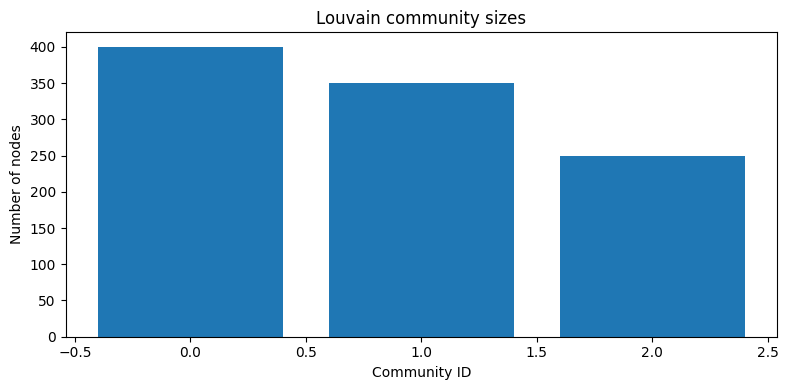

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(louvain_sizes)), louvain_sizes)
plt.title("Louvain community sizes")
plt.xlabel("Community ID")
plt.ylabel("Number of nodes")
plt.tight_layout()
plt.show()

In [ ]:
perm = np.random.permutation(num_nodes)

train_size = int(0.60 * num_nodes)
val_size   = int(0.20 * num_nodes)
test_size  = num_nodes - train_size - val_size

train_idx = perm[:train_size]
val_idx   = perm[train_size:train_size + val_size]
test_idx  = perm[train_size + val_size:]

y = true_labels.copy()

# -----------------------------------------------------------------------------
# Step 2: Fit logistic regression on features only
# -----------------------------------------------------------------------------
lr = LogisticRegression(max_iter=200)
lr.fit(X[train_idx], y[train_idx])

yhat_val_lr  = lr.predict(X[val_idx])
yhat_test_lr = lr.predict(X[test_idx])

val_acc_lr  = accuracy_score(y[val_idx], yhat_val_lr)
test_acc_lr = accuracy_score(y[test_idx], yhat_test_lr)

print("\nBaseline (features-only) logistic regression:")
print("  Validation accuracy:", val_acc_lr)
print("  Test accuracy:", test_acc_lr)


Baseline (features-only) logistic regression:
  Validation accuracy: 0.945
  Test accuracy: 0.975


Epoch 1 | loss: 1.1477802991867065 | train_acc: 0.3449999988079071 | val_acc: 0.36500000953674316 | test_acc: 0.3499999940395355
Epoch 2 | loss: 1.1140285730361938 | train_acc: 0.3449999988079071 | val_acc: 0.36500000953674316 | test_acc: 0.3499999940395355
Epoch 3 | loss: 1.0826900005340576 | train_acc: 0.4266666769981384 | val_acc: 0.4449999928474426 | test_acc: 0.4449999928474426
Epoch 4 | loss: 1.0528230667114258 | train_acc: 0.7350000143051147 | val_acc: 0.7850000262260437 | test_acc: 0.7549999952316284
Epoch 5 | loss: 1.0238466262817383 | train_acc: 0.7366666793823242 | val_acc: 0.7850000262260437 | test_acc: 0.7549999952316284
Epoch 6 | loss: 0.995237410068512 | train_acc: 0.7366666793823242 | val_acc: 0.7850000262260437 | test_acc: 0.7549999952316284
Epoch 7 | loss: 0.9666808247566223 | train_acc: 0.7366666793823242 | val_acc: 0.7850000262260437 | test_acc: 0.7549999952316284
Epoch 8 | loss: 0.937896192073822 | train_acc: 0.7366666793823242 | val_acc: 0.7850000262260437 | test_

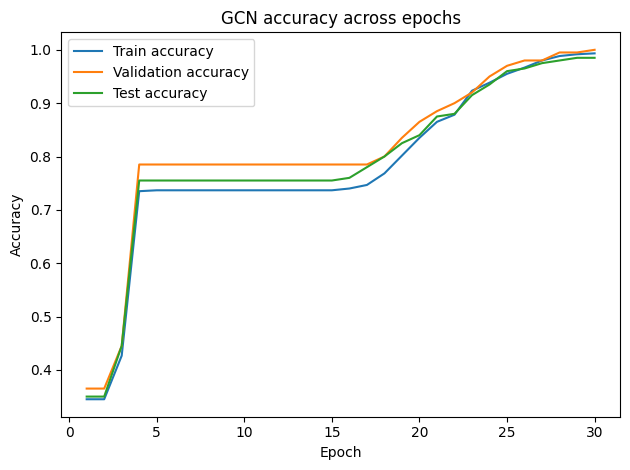

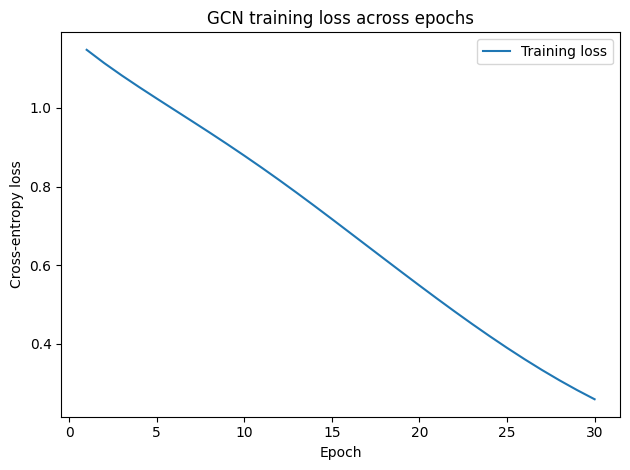

In [ ]:
I = sp.eye(num_nodes, format="csr", dtype=np.float32)
A_tilde = A + I

deg_tilde = np.array(A_tilde.sum(axis=1)).flatten()
deg_inv_sqrt = 1.0 / np.sqrt(deg_tilde)

D_inv_sqrt = sp.diags(deg_inv_sqrt.astype(np.float32), format="csr")
A_norm = D_inv_sqrt @ A_tilde @ D_inv_sqrt

# -----------------------------------------------------------------------------
# Step 2: Convert data to PyTorch tensors
# -----------------------------------------------------------------------------
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

# Convert A_norm to a torch sparse tensor
A_norm_coo = A_norm.tocoo()
A_indices = torch.tensor(
    np.vstack((A_norm_coo.row, A_norm_coo.col)),
    dtype=torch.long
)
A_values = torch.tensor(A_norm_coo.data, dtype=torch.float32)
A_norm_t = torch.sparse_coo_tensor(A_indices, A_values, size=(num_nodes, num_nodes)).coalesce()

train_idx_t = torch.tensor(train_idx, dtype=torch.long)
val_idx_t   = torch.tensor(val_idx, dtype=torch.long)
test_idx_t  = torch.tensor(test_idx, dtype=torch.long)

# -----------------------------------------------------------------------------
# Step 3: Define GCN parameters (two linear layers)
# -----------------------------------------------------------------------------
hidden_dim = 16
num_classes = num_blocks

lin1 = nn.Linear(num_features, hidden_dim)
lin2 = nn.Linear(hidden_dim, num_classes)

optimizer = torch.optim.Adam(list(lin1.parameters()) + list(lin2.parameters()), lr=0.01, weight_decay=5e-4)

# -----------------------------------------------------------------------------
# Step 4: Training loop (explicit; prints each epoch)
# -----------------------------------------------------------------------------
# We do 30 epochs to keep the output manageable in class.
epochs = 30

# Store training history so we can visualize performance across epochs
epoch_list = []
loss_history = []
train_acc_history = []
val_acc_history = []
test_acc_history = []

for epoch in range(1, epochs + 1):

    # Forward pass
    H0 = lin1(X_t)
    H1 = torch.sparse.mm(A_norm_t, H0)
    H1 = torch.relu(H1)

    Z0 = lin2(H1)
    logits = torch.sparse.mm(A_norm_t, Z0)

    # Loss on training nodes only
    loss = F.cross_entropy(logits[train_idx_t], y_t[train_idx_t])

    # Backprop + update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accuracy (train/val/test)
    preds = torch.argmax(logits, dim=1)

    train_acc = (preds[train_idx_t] == y_t[train_idx_t]).float().mean().item()
    val_acc   = (preds[val_idx_t]   == y_t[val_idx_t]).float().mean().item()
    test_acc  = (preds[test_idx_t]  == y_t[test_idx_t]).float().mean().item()

    print("Epoch", epoch, "| loss:", float(loss.detach().cpu().numpy()),
          "| train_acc:", train_acc, "| val_acc:", val_acc, "| test_acc:", test_acc)
    # Save values for plotting after training
    epoch_list.append(epoch)
    loss_history.append(float(loss.detach().cpu().numpy()))
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    test_acc_history.append(test_acc)


# -----------------------------------------------------------------------------
# Spaghetti-style training curves
# -----------------------------------------------------------------------------
# This shows how train / validation / test accuracy move across epochs.
# We also plot loss separately so students can compare optimization vs accuracy.

history_df = pd.DataFrame({
    "epoch": epoch_list,
    "loss": loss_history,
    "train_acc": train_acc_history,
    "val_acc": val_acc_history,
    "test_acc": test_acc_history
})

# Accuracy spaghetti plot
plt.figure()
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation accuracy")
plt.plot(history_df["epoch"], history_df["test_acc"], label="Test accuracy")
plt.title("GCN accuracy across epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Loss plot
plt.figure()
plt.plot(history_df["epoch"], history_df["loss"], label="Training loss")
plt.title("GCN training loss across epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
val_acc_gcn = accuracy_score(y[val_idx], preds_np[val_idx])
test_acc_gcn = accuracy_score(y[test_idx], test_pred_gcn)

print("\nGCN final performance:")
print("  Validation accuracy:", val_acc_gcn)
print("  Test accuracy:", test_acc_gcn)


GCN final performance:
  Validation accuracy: 1.0
  Test accuracy: 0.985
